# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Dieuwke Meindertsma
* Username: dmeindertsma
* Student number: s6446493
* Group (AS1, etc.): AS6

-----

In [1]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [2]:
import numpy as np
import sympy as sp
from scipy.integrate import quad
import random

class NumericalIntegration:
    def __init__(self, func_str, a, b):
        """A class for numerical integration of a function on a given interval [a, b]."""
        self.func_str = func_str
        self.a = a
        self.b = b
        
        # Sympy variable
        self.x = sp.symbols('x')
        
        # Sympy expression
        self.func_sympy = sp.sympify(func_str)
        
        # Function for scipy and numpy
        self.func = sp.lambdify(self.x, self.func_sympy, 'numpy')
    
# Trapezium rule
    def trapezium(self):
        """Compute the integral using the trapezium rule."""
        fa = self.func(self.a)
        fb = self.func(self.b)
    
        return (self.b - self.a) * (fa + fb) / 2
    
# Simpson’s rule
    def simpson(self, n=1000):
        """Compute the integral using Simpson's rule with n points."""
        if n % 2 == 1:
            n += 1
        
        x = np.linspace(self.a, self.b, n)
        y = self.func(x)
        h = (self.b - self.a) / (n - 1)
        
        return (h/3) * (y[0] + 4 * y[1:-1:2].sum() + 2 * y[2:-2:2].sum() + y[-1])
    
# Monte Carlo
    def monte_carlo(self, n=10000):
        """Estimate the integral using Monte Carlo."""
        xs = np.random.uniform(self.a, self.b, n)
        ys = self.func(xs)
        
        return (self.b - self.a) * np.mean(ys)
    
# SymPy 
    def sympy_integral(self):
        """Compute the exact integral using SymPy."""
        result = sp.integrate(self.func_sympy, (self.x, self.a, self.b))
        return float(result)
    
# SciPy quad
    def scipy_quad(self):
        """Compute the integral using SciPy's quad function."""
        result, _ = quad(self.func, self.a, self.b)
        return result

# Test
ni = NumericalIntegration("sin(x) + x**2", 0.5, 3.0)

print("Trapezium rule:", ni.trapezium())
print("Simpson rule:", ni.simpson())
print("Monte Carlo:", ni.monte_carlo())
print("SymPy integral:", ni.sympy_integral())
print("SciPy quad:", ni.scipy_quad())

Trapezium rule: 12.338181933330086
Simpson rule: 10.803058852476761
Monte Carlo: 10.897206943629383
SymPy integral: 10.825908391824152
SciPy quad: 10.825908391824154


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

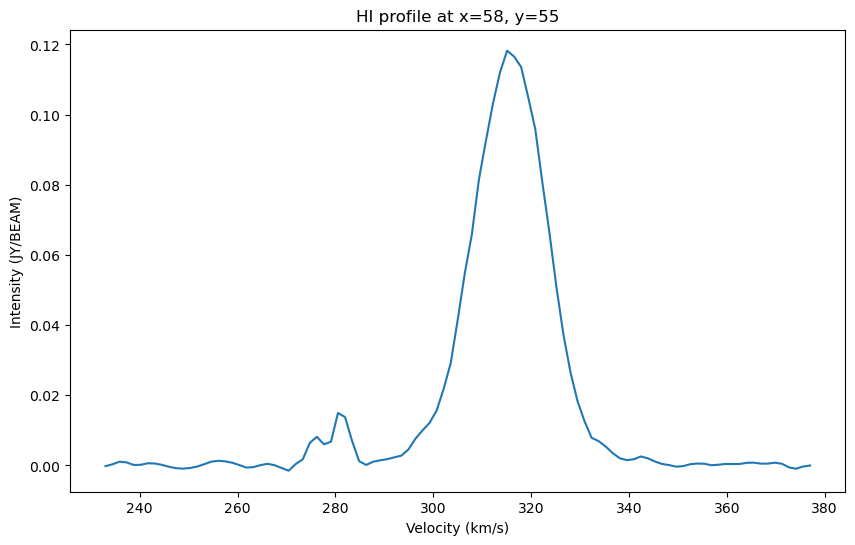

In [4]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

hdul=fits.open('ngc6946.fits')
data = hdul[0].data
header= hdul[0].header


x_index = 58
y_index = 55

cube = data
profile = cube[:, y_index, x_index]
vel=np.linspace(233,377,profile.size)

x_unit = header["CUNIT3"]
y_unit = header["BUNIT"]

plt.figure(figsize=(10,6))
plt.plot(vel, profile)
plt.xlabel(f"Velocity ({x_unit})")
plt.ylabel(f"Intensity ({y_unit})")
plt.title("HI profile at x=58, y=55")
plt.show()

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [6]:
def f(x, amp, mu, sigma, zero):
    """Return the value of a Gaussian function with amplitude amp centered at position mu with width sigma and offset with respect to the x axis of zero"""
    return amp*np.exp((-(x-mu)**2)/2*sigma**2)+zero

In [7]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

The Gaussian model is non-linear in the parameters, because mu and sigma are inside the exponential function. So the model can't be expressed as a linear combination of basis functions that depend on x only.

In [8]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [9]:
import numpy as np
from scipy.optimize import curve_fit
from astropy.io import fits

hdul=fits.open('ngc6946.fits')
data = hdul[0].data
header= hdul[0].header

x_index = 58
y_index = 55

cube = data
profile = cube[:, y_index, x_index]
vel=np.linspace(233,377,profile.size)

def f(x, amp, mu, sigma, zero):
    """Return the value of a Gaussian function with amplitude amp centered at position mu with width sigma and offset with respect to the x axis of zero"""
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) + zero

# The minimum value as the baseline:
zero0 = 0.
# The amplitude would be the max value minus the baseline
amp0 = np.max(profile)
# The center of the peak at the index of the max:
mu0 = vel[np.argmax(profile)]
# Form looking at the graph:
sigma0 = 20.
# Make initial parameter list:
p0 = [amp0, mu0, sigma0, zero0]

# Curve fitting:

popt, pcov = curve_fit(f, vel, profile, p0=p0)
# Parameters and errors
amp, mu, sigma, zero = popt
perr = np.sqrt(np.diag(pcov))
damp, dmu, dsigma, dzero = perr

print("Best-fit parameters:")
print(f"amp   = {amp:.3f} ± {damp:.6f}")
print(f"mu    = {mu:.3f} ± {dmu:.6f} km/s")
print(f"sigma = {sigma:.3f} ± {dsigma:.6f} km/s")
print(f"zero  = {zero:.3f} ± {dzero:.6f}")

Best-fit parameters:
amp   = 0.117 ± 0.001098
mu    = 315.717 ± 0.077180 km/s
sigma = 7.261 ± 0.081697 km/s
zero  = 0.001 ± 0.000305


In [10]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

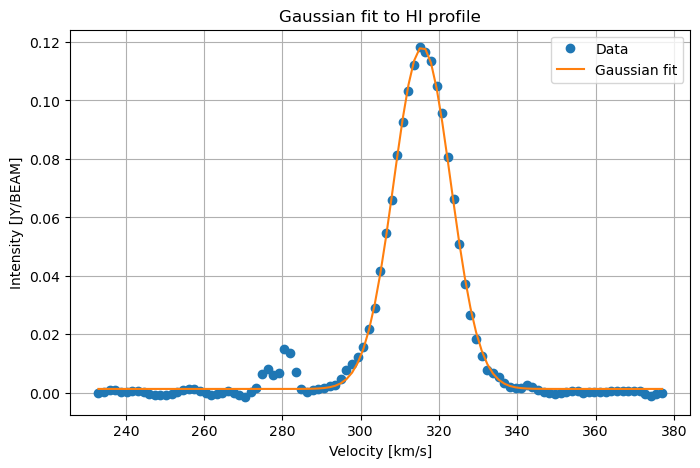

In [11]:
# first from the previous exercise:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.io import fits

hdul=fits.open('ngc6946.fits')
data = hdul[0].data
header= hdul[0].header

x_index = 58
y_index = 55

cube = data
profile = cube[:, y_index, x_index]
vel=np.linspace(233,377,profile.size)

def f(x, amp, mu, sigma, zero):
    """Return the value of a Gaussian function with amplitude amp centered at position mu with width sigma and offset with respect to the x axis of zero"""
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) + zero

# The minimum value as the baseline:
zero0 = 0.
# The amplitude would be the max value minus the baseline
amp0 = np.max(profile)
# The center of the peak at the index of the max:
mu0 = vel[np.argmax(profile)]
# Form looking at the graph:
sigma0 = 20.
# Make initial parameter list:
p0 = [amp0, mu0, sigma0, zero0]


popt, pcov = curve_fit(f, vel, profile, p0=p0)
# Parameters and errors
amp, mu, sigma, zero = popt
perr = np.sqrt(np.diag(pcov))
damp, dmu, dsigma, dzero = perr

# now for 5:
fit = f(vel, amp, mu, sigma, zero)
# plot
plt.figure(figsize=(8,5))

plt.plot(vel, profile, 'o', label='Data')
plt.plot(vel, fit, '-', label='Gaussian fit')

# labels
plt.xlabel(f"Velocity [{header['CUNIT3']}]")
plt.ylabel(f"Intensity [{header['BUNIT']}]")
plt.title("Gaussian fit to HI profile")

plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

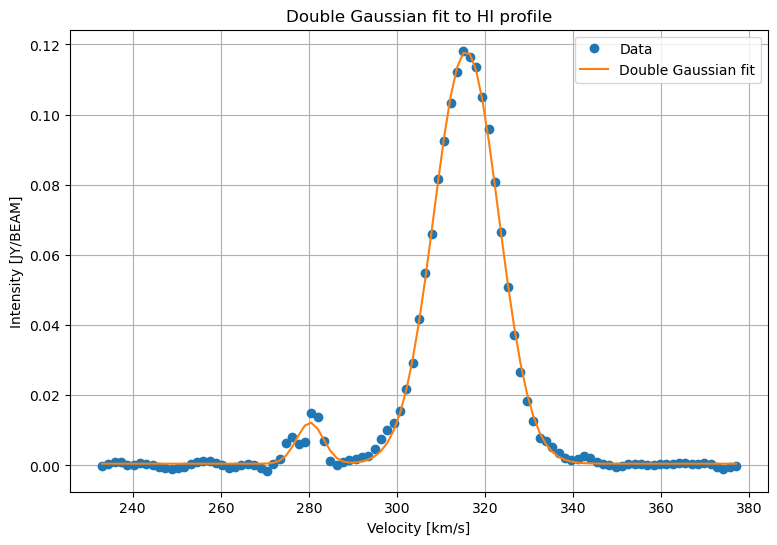

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.io import fits

hdul=fits.open('ngc6946.fits')
data = hdul[0].data
header= hdul[0].header

x_index = 58
y_index = 55

cube = data
profile = cube[:, y_index, x_index]
vel=np.linspace(233,377,profile.size)

x_index = 58
y_index = 55

profile = cube[:, y_index, x_index]

# velocity axis
vel = np.linspace(233, 377, profile.size)

# Double Gaussian model

def f2(x, A1, M1, S1, A2, M2, S2, zero):
    """Return the value of two Gaussian functions with amplitude A1, A2 centered at position M1, M2 with width S1, S2 and offset with respect to the x axis of zero"""
    g1 = A1 * np.exp(-((x - M1)**2) / (2 * S1**2))   # main peak
    g2 = A2 * np.exp(-((x - M2)**2) / (2 * S2**2))   # secondary peak
    return g1 + g2 + zero

# Initial estimates based on plots

p0 = [
    0.12, 315, 12,    # main peak
    0.015, 280, 5,    # secondary peak
    0.0               # baseline
]

# fit
popt2, pcov2 = curve_fit(
    f2, vel, profile,
    p0=p0)

# standard errors
perr2 = np.sqrt(np.diag(pcov2))

# unpack parameters
A1, M1, S1, A2, M2, S2, zero = popt2
dA1, dM1, dS1, dA2, dM2, dS2, dzero = perr2

#plot

fit = f2(vel, *popt2)

plt.figure(figsize=(9,6))

# data
plt.plot(vel, profile, 'o', label='Data')

# total fit
plt.plot(vel, fit, '-', label='Double Gaussian fit')

# labels
plt.xlabel(f"Velocity [{header['CUNIT3']}]")
plt.ylabel(f"Intensity [{header['BUNIT']}]")
plt.title("Double Gaussian fit to HI profile")

plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [15]:
factor = 2 * np.sqrt(2 * np.log(2))

# FWHM
FWHM1 = factor * S1
FWHM2 = factor * S2

# errors
dFWHM1 = factor * dS1
dFWHM2 = factor * dS2

print(f"Main peak FWHM      = {FWHM1:.2f} ± {dFWHM1:.2f} km/s")
print(f"Secondary peak FWHM = {FWHM2:.2f} ± {dFWHM2:.2f} km/s")

Main peak FWHM      = 17.27 ± 0.11 km/s
Secondary peak FWHM = 7.12 ± 0.68 km/s


In [16]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

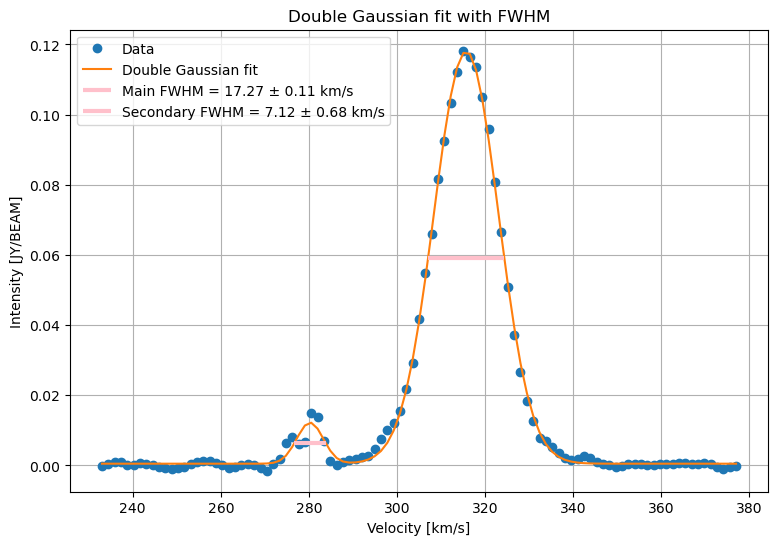

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Half height
y_half1 = zero + A1 / 2
y_half2 = zero + A2 / 2

# x-range for FWHM
x1_left = M1 - FWHM1 / 2
x1_right = M1 + FWHM1 / 2

x2_left = M2 - FWHM2 / 2
x2_right = M2 + FWHM2 / 2

plt.figure(figsize=(9,6))

# data + fit
plt.plot(vel, profile, 'o', label='Data')
plt.plot(vel, fit, '-', label='Double Gaussian fit')

# FWHM lijnen (HORIZONTAAL!)
plt.hlines(y_half1, x1_left, x1_right,
           linewidth=3, color = "pink",
           label=f'Main FWHM = {FWHM1:.2f} ± {dFWHM1:.2f} km/s')

plt.hlines(y_half2, x2_left, x2_right,
           linewidth=3, color = "pink",
           label=f'Secondary FWHM = {FWHM2:.2f} ± {dFWHM2:.2f} km/s')

# labels
plt.xlabel(f"Velocity [{header['CUNIT3']}]")
plt.ylabel(f"Intensity [{header['BUNIT']}]")
plt.title("Double Gaussian fit with FWHM")

plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   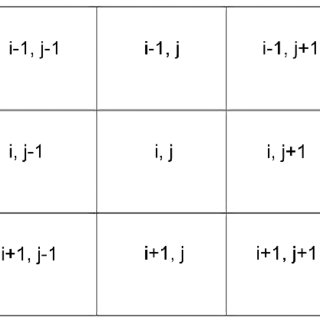    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

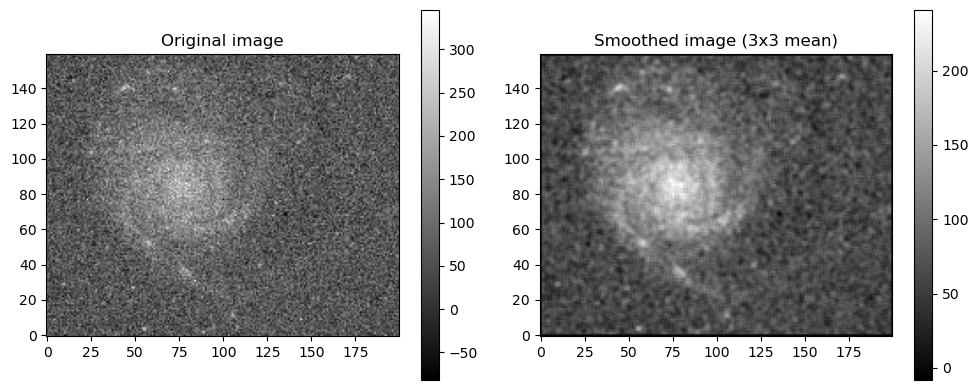

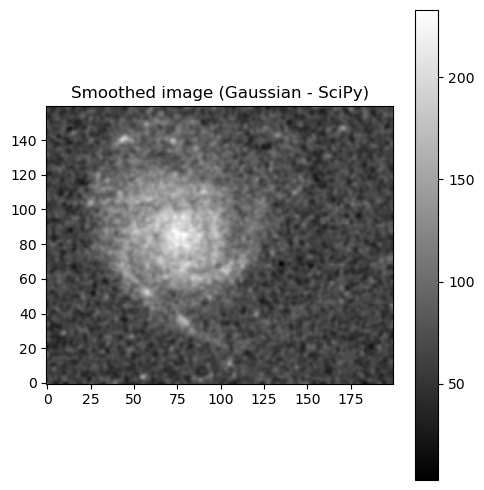

In [19]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy import ndimage

hdul=fits.open('faintgalaxy.fits')
M = hdul[0].data

def smooth(M):
    """Smooth a 2D image by replacing each pixel with the mean of its 3x3 neighbourhood, not including the bounds."""
    
    Mc = np.zeros_like(M)   # new image

    ny, nx = M.shape        # empty memory

    for y, x in np.ndindex(M.shape):

        # Not including the border pixels
        if y == 0 or y == ny-1 or x == 0 or x == nx-1:
            continue
            
        block = M[y-1:y+2, x-1:x+2]
        # mean
        Mc[y, x] = np.mean(block)

    return Mc

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(M, cmap='gray', origin='lower')
plt.title("Original image")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(smooth(M), cmap='gray', origin='lower')
plt.title("Smoothed image (3x3 mean)")
plt.colorbar()

plt.tight_layout()
plt.show()

# Second method in different plot:

def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc

plt.figure(figsize=(5,5))

plt.imshow(smooth2(M), cmap='gray', origin='lower')
plt.title("Smoothed image (Gaussian - SciPy)")
plt.colorbar()

plt.tight_layout()
plt.show()

In [20]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [21]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 25. Student score: 0.0.  Task Grade = 0.0
